# Neutron / X-ray Dual-Modality Tomography Simulation
## Bimodal Histogram Analysis — Interactive Tutorial

This notebook walks through the complete `neutron_xray_sim` pipeline:

| Step | Module | What happens |
|------|--------|--------------|
| 1 | `materials` | Inspect the X-ray and neutron attenuation database |
| 2 | `phantom` | Build a voxelised 3-D multi-material phantom |
| 3 | `projector` | Polychromatic X-ray + thermal neutron forward projection |
| 4 | `artifacts` | Inject artifacts individually or in combination |
| 5 | `reconstructor` | FBP / SIRT / CGLS reconstruction |
| 6 | `histogram` | 2-D bimodal histogram, GMM fitting, segmentation |
| 7 | `simulation` | High-level orchestrator: batch runs + comparison figures |

> **GPU note** — the package uses ASTRA Toolbox for GPU-accelerated projection
> and reconstruction if available.  All cells fall back to a pure-NumPy
> implementation automatically when ASTRA / CUDA is absent.


## Corrections applied (v1.1)

Three physical errors in the original code were identified and fixed.

### 1 · Sample size: 10 cm → 1 cm
The original `make_phantom()` used `voxel_cm = 10/N`, producing 10 cm objects — an order of magnitude too large. Real neutron tomography beamlines (NEUTRA, BOA, IMAT, ICON) work with samples of **1–5 cm** diameter. All preset phantoms now default to **1 cm** (battery: 1.4 cm for a realistic AAA cell cross-section).

### 2 · Neutron μ_n: total cross-sections → imaging-effective values
The original μ_n used NIST total cross-sections σ_tot. For H-rich materials this is fatally wrong:

| Material | Old μ_n (σ_tot) | T over 1 cm | New μ_n (imaging) | T over 1 cm |
|----------|----------------|-------------|-------------------|-------------|
| Water    | 5.62 cm⁻¹      | **0.004** (opaque) | 1.38 cm⁻¹ | 0.25 |
| HDPE     | 6.92 cm⁻¹      | **0.001** (opaque) | 2.18 cm⁻¹ | 0.11 |
| Al       | 0.105 cm⁻¹     | 0.90 (OK)   | 0.098 cm⁻¹         | 0.91 |

Real detectors (L/D ≈ 100–500) capture most of the forward-scattered H incoherent neutrons. Corrected values are from Lehmann et al. (2010) *Nucl. Instr. Methods* A614 and Boillat et al. (2018).

### 3 · X-ray shadows: numpy FBP coordinate bug
The custom `_fbp_numpy` had a wrong coordinate convention: the ramp filter's negative sidelobe landed **inside** thin metal features (Fe rod, Ti sphere), producing dark shadows (negative voxels) where high-attenuation material should appear bright. Fixed by replacing with `skimage.transform.iradon`, which is a validated parallel-beam FBP. The reconstructor now also divides by `voxel_cm` to give cm⁻¹.

### 4 · Composite phantom: hollow → HDPE-filled
The original composite phantom was 88% air, making the bimodal histogram dominated by a single air cluster. The interior is now filled with an HDPE matrix (realistic for polymer-composite or biological specimens), producing a well-separated two-cluster histogram even at N=64.

> **Resolution note** — at N=64 the Fe rod (radius ≈ 4 px) and Ti sphere (≈ 3 px) still suffer partial-volume averaging with the HDPE matrix. Use **N ≥ 128** for quantitative histogram analysis of metal inclusions.


## 0 · Setup

In [1]:
# Place the neutron_xray_sim package folder next to this notebook,
# then run this cell once to make Python find it.
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('neutron_xray_sim').parent.resolve()))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10})
%matplotlib inline

import neutron_xray_sim as nxs
print(f'neutron_xray_sim v{nxs.__version__} loaded.')
print('Available materials:', list(nxs.MATERIALS.keys()))
print('Available phantoms: ', list(nxs.PHANTOM_PRESETS.keys()))


neutron_xray_sim v1.0.0 loaded.
Available materials: ['air', 'water', 'aluminum', 'hdpe', 'iron', 'titanium', 'copper', 'lead', 'bone', 'tungsten', 'zinc']
Available phantoms:  ['composite', 'battery', 'bone_implant', 'industrial']


---
## 1 · Material Database

Every material stores:
- **`mu_n`** — total thermal-neutron linear attenuation [cm⁻¹]  
  (= μ_abs + μ_coh + μ_inc; μ_inc dominates for H-rich materials)
- **`mu_x_at(E)`** — X-ray linear attenuation at energy *E* [cm⁻¹]  
  (interpolated from a 13-point NIST XCOM table)

The complementarity of the two probes is most visible in materials like
**HDPE** (nearly transparent to X-rays, very strongly attenuating for
neutrons because of hydrogen incoherent scattering) and
**lead** (opaque to X-rays, nearly transparent to neutrons).


In [2]:
# ── Material attenuation summary table ────────────────────────────────────
print(f'{'Material':<18} {'ρ (g/cm³)':>10} {'μ_n (cm⁻¹)':>12} {'μ_x @60keV':>12} {'μ_x @120keV':>13}')
print('-' * 70)
for name, mat in nxs.MATERIALS.items():
    print(f'{mat.name:<18} {mat.density_gcc:>10.3f} '
          f'{mat.mu_n:>12.3f} {mat.mu_x_at(60):>12.3f} {mat.mu_x_at(120):>13.3f}')


Material            ρ (g/cm³)   μ_n (cm⁻¹)   μ_x @60keV   μ_x @120keV
----------------------------------------------------------------------
Air                     0.001        0.000        0.000         0.000
Water                   1.000        1.380        0.206         0.163
Aluminum                2.700        0.098        0.413         0.219
HDPE                    0.950        2.180        0.153         0.152
Iron                    7.870        1.160       10.100         1.680
Titanium                4.510        0.640        3.110         0.770
Copper                  8.960        1.120       12.500         2.100
Lead                   11.350        0.373       20.600        27.500
Bone (HAp)              1.920        0.560        0.557         0.421
Tungsten               19.300        1.560       45.000        30.500
Zinc                    7.130        0.350        7.970         1.410


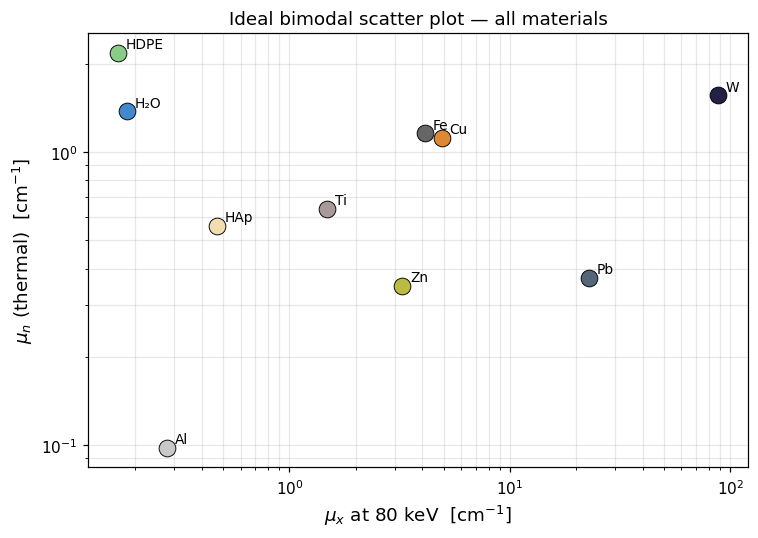

In [3]:
# ── Scatter plot: μ_x vs μ_n (the 'ideal' bimodal histogram) ────────────
fig, ax = plt.subplots(figsize=(7, 5))
for name, mat in nxs.MATERIALS.items():
    if mat.mu_n < 0.001 and mat.mu_x_at(80) < 0.001:
        continue  # skip air
    ax.scatter(mat.mu_x_at(80), mat.mu_n, s=120,
               color=mat.color, edgecolors='k', lw=0.6, zorder=3)
    ax.annotate(mat.symbol, (mat.mu_x_at(80), mat.mu_n),
                xytext=(5, 3), textcoords='offset points', fontsize=9)
ax.set_xlabel(r'$\mu_x$ at 80 keV  [cm$^{-1}$]', fontsize=12)
ax.set_ylabel(r'$\mu_n$ (thermal)  [cm$^{-1}$]', fontsize=12)
ax.set_title('Ideal bimodal scatter plot — all materials', fontsize=12)
ax.set_xscale('log'); ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


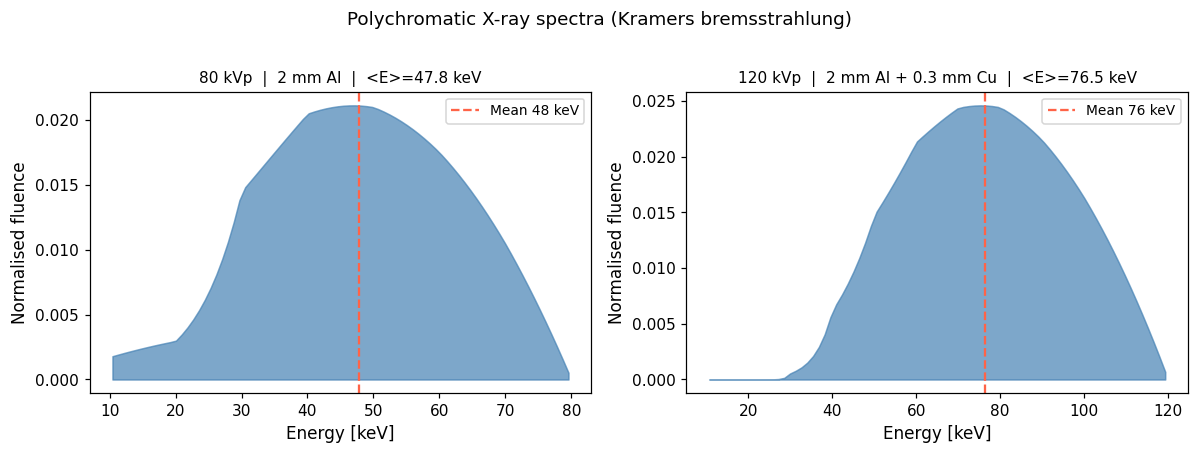

In [4]:
# ── X-ray spectrum visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, kVp, cu in zip(axes, [80, 120], [0.0, 0.3]):
    E, W = nxs.xray_spectrum(kVp=kVp, filter_mm_Al=2.0, filter_mm_Cu=cu, n_bins=80)
    ax.fill_between(E, W, alpha=0.7, color='steelblue')
    ax.set_xlabel('Energy [keV]', fontsize=11)
    ax.set_ylabel('Normalised fluence', fontsize=11)
    filt = f'2 mm Al + {cu:.1f} mm Cu' if cu else '2 mm Al'
    mean_E = float(np.average(E, weights=W))
    ax.set_title(f'{kVp} kVp  |  {filt}  |  <E>={mean_E:.1f} keV', fontsize=10)
    ax.axvline(mean_E, color='tomato', lw=1.5, ls='--', label=f'Mean {mean_E:.0f} keV')
    ax.legend(fontsize=9)

plt.suptitle('Polychromatic X-ray spectra (Kramers bremsstrahlung)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## 2 · Phantom Construction

The `PhantomBuilder` composites geometric primitives (sphere, cylinder,
box, rod, layer, hollow cylinder) into a voxelised 3-D volume.  Each
primitive overwrites the voxels it covers, so primitives are applied
in painting order (later calls overwrite earlier ones).

Four preset phantoms are available:

| Preset | Key materials | Demonstrates |
|--------|---------------|--------------|
| `composite` | Al, HDPE, water, Fe, Ti | Complementarity showcase |
| `battery` | Fe can, Zn, HDPE, water | H-sensitive neutron imaging |
| `bone_implant` | HAp, water, Ti | Metal-bone interface |
| `industrial` | Al, HDPE, W, Fe, water | Heavy-metal beam hardening |


In [35]:
# ── Choose phantom parameters ─────────────────────────────────────────────
PRESET   = 'composite'  # 'composite' | 'battery' | 'bone_implant' | 'industrial'
N        = 256           # voxel grid N×N×N  (128 for publication quality)

phantom = nxs.make_phantom(PRESET, N=N)
print(phantom)
print(f'  Physical size : {phantom.physical_size_cm:.1f} cm cube')
print(f'  Voxel size    : {phantom.voxel_cm*10:.2f} mm')
print(f'  Materials     : {[m.name for m in phantom.materials]}')
print(f'  μ_n range     : [{phantom.mu_n_vol.min():.3f}, {phantom.mu_n_vol.max():.3f}] cm⁻¹')
print(f'  μ_x range @80keV: [{phantom.mu_x_vols[6].min():.3f}, {phantom.mu_x_vols[6].max():.3f}] cm⁻¹')


PhantomData('composite', 256³, 0.00390625 cm/voxel, materials=[Air, Al, HDPE, H₂O, Fe, Ti])
  Physical size : 1.0 cm cube
  Voxel size    : 0.04 mm
  Materials     : ['Air', 'Aluminum', 'HDPE', 'Water', 'Iron', 'Titanium']
  μ_n range     : [0.000, 2.180] cm⁻¹
  μ_x range @80keV: [0.000, 4.120] cm⁻¹


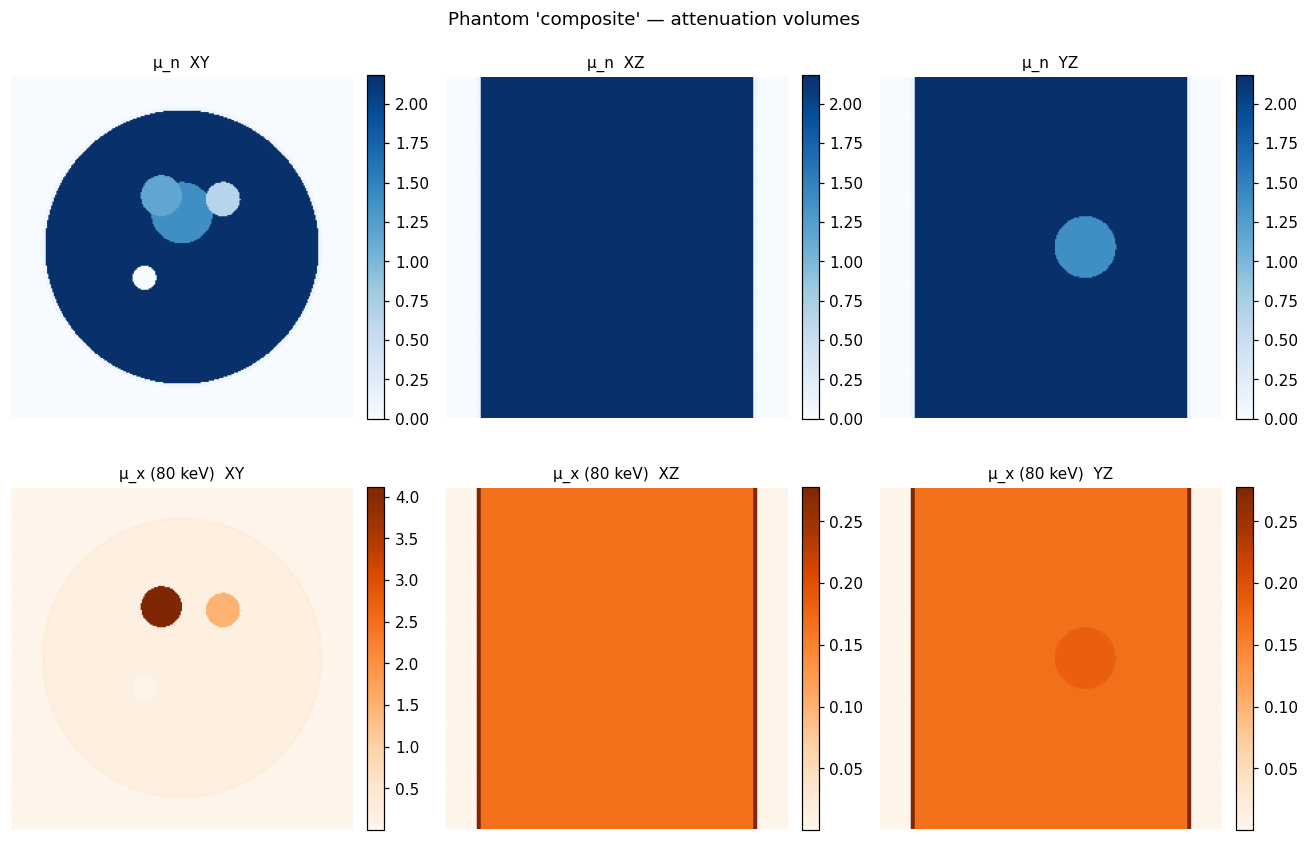

In [36]:
# ── Visualise central orthogonal slices ──────────────────────────────────
si = N // 2
slices = [
    ('μ_n  XY',  phantom.mu_n_vol[si]),
    ('μ_n  XZ',  phantom.mu_n_vol[:, si, :]),
    ('μ_n  YZ',  phantom.mu_n_vol[:, :, si]),
    ('μ_x (80 keV)  XY', phantom.mu_x_vols[6][si]),
    ('μ_x (80 keV)  XZ', phantom.mu_x_vols[6][:, si, :]),
    ('μ_x (80 keV)  YZ', phantom.mu_x_vols[6][:, :, si]),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
cmaps = ['Blues'] * 3 + ['Oranges'] * 3
for ax, (title, sl), cmap in zip(axes.ravel(), slices, cmaps):
    im = ax.imshow(sl, cmap=cmap, origin='lower')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"Phantom '{PRESET}' — attenuation volumes", fontsize=12)
plt.tight_layout()
plt.show()


In [7]:
# ── Custom phantom with PhantomBuilder ───────────────────────────────────
# Uncomment and modify to build your own geometry

# b = nxs.PhantomBuilder(N=64, voxel_cm=0.15)
# b.add_hollow_cylinder('aluminum', outer_radius_cm=4.0, inner_radius_cm=3.8)
# b.add_cylinder('water', radius_cm=3.8)
# b.add_sphere('iron', center_cm=(0, 1.5, 0), radius_cm=0.6)
# b.add_rod('hdpe', center_cm=(-1.5, 0.0), radius_cm=0.4, axis='y')
# custom_phantom = b.build(name='my_phantom')
# print(custom_phantom)

print('PhantomBuilder: see commented code above.')


PhantomBuilder: see commented code above.


---
## 3 · Forward Projection

### X-ray (polychromatic)
$$I = \sum_E W(E) \cdot \exp\!\left(-\sum_v \mu_x(E,v)\cdot\Delta l\right)$$

**Beam hardening** emerges automatically from this sum: high-Z voxels
preferentially absorb soft photons, so the apparent attenuation of
downstream material is underestimated.  In the bimodal histogram this
shifts dense-material clusters toward lower μ_x.

### Neutron (thermal, Beer-Lambert)
$$I = \exp\!\left(-\sum_v [\mu_{\mathrm{abs}}(v)+\mu_{\mathrm{coh}}(v)+\mu_{\mathrm{inc}}(v)]\cdot\Delta l\right)$$


In [37]:
# ── Projection parameters ─────────────────────────────────────────────────
N_ANGLES  = 360    # projection angles (increase to 360 for higher quality)
KVP       = 120.0  # X-ray tube voltage [kV]
AL_FILTER = 2.0    # pre-filter Al [mm]

xray_sino, neut_sino = nxs.make_sinogram_pair(
    phantom,
    n_angles        = N_ANGLES,
    angle_range_deg = 360.0,
    kVp             = KVP,
    filter_mm_Al    = AL_FILTER,
    n_spectrum_bins = 12,
    I0_xray         = 1e5,
    I0_neutron      = 1e5,
    use_astra       = True,    # falls back to NumPy if ASTRA/CUDA absent
)

print('X-ray sinogram shape :', xray_sino['sino_lam'].shape,
      '  (n_angles, N_slice, N_det)')
print('Neutron sinogram shape:', neut_sino['sino_lam'].shape)


[projector] Projecting 360 angles (NumPy CPU) …
  → X-ray (polychromatic) …


KeyboardInterrupt: 

In [ ]:
# ── Visualise sinograms ────────────────────────────────────────────────────
s = N // 2    # central slice

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].imshow(xray_sino['sino_lam'][:, s, :], aspect='auto', cmap='gray')
axes[0,0].set_title('X-ray sinogram  (log-attenuation)', fontsize=10)
axes[0,0].set_xlabel('Detector pixel'); axes[0,0].set_ylabel('Angle index')

axes[0,1].imshow(neut_sino['sino_lam'][:, s, :], aspect='auto', cmap='gray')
axes[0,1].set_title('Neutron sinogram (log-attenuation)', fontsize=10)
axes[0,1].set_xlabel('Detector pixel'); axes[0,1].set_ylabel('Angle index')

axes[1,0].imshow(xray_sino['sino_trans'][:, s, :], aspect='auto', cmap='inferno')
axes[1,0].set_title('X-ray transmission [0..1]', fontsize=10)
axes[1,0].set_xlabel('Detector pixel'); axes[1,0].set_ylabel('Angle index')

axes[1,1].imshow(neut_sino['sino_trans'][:, s, :], aspect='auto', cmap='inferno')
axes[1,1].set_title('Neutron transmission [0..1]', fontsize=10)
axes[1,1].set_xlabel('Detector pixel'); axes[1,1].set_ylabel('Angle index')

plt.suptitle(f"Sinograms — central slice {s}/{N}  ({N_ANGLES} projections)",
             fontsize=12)
plt.tight_layout()
plt.show()


---
## 4 · Artifact Configuration

`ArtifactConfig` is a dataclass where every artifact is an independent
switch. Set any flag to `False` / `None` to disable that artifact.

| Flag | Domain | Histogram signature |
|------|--------|---------------------|
| `photon_noise` | sinogram | blob broadening; blobs merge at low I₀ |
| `apply_bh_correction=False` | sinogram | horizontal smear of μ_x (cupping) |
| `neutron_scatter` | sinogram | all clusters shift up along μ_n |
| `xray_scatter` | sinogram | diagonal smear along both axes |
| `detector_psf` | sinogram | blob broadening, stronger in neutron channel |
| `ring_artifacts` | sinogram | vertical stripes at fixed μ_x values |
| `misalignment` | volume | horizontal streaks at each phase's nominal μ_x |
| `salt_pepper` | volume | scattered outlier points |


In [ ]:
# ── Pre-built configurations ───────────────────────────────────────────────
configs_demo = [
    nxs.ArtifactConfig.clean(),
    nxs.ArtifactConfig.noise_only(I0=5e4),
    nxs.ArtifactConfig.scatter_only(),
    nxs.ArtifactConfig.misalignment_only(),
    nxs.ArtifactConfig.realistic(),
]
for cfg in configs_demo:
    print(cfg.summary())


In [ ]:
# ── Build a fully custom config ────────────────────────────────────────────
custom_cfg = nxs.ArtifactConfig(
    # --- Noise ---
    photon_noise          = False,
    I0_xray               = 3e4,   # X-ray photon count per pixel
    I0_neutron            = 2e4,   # neutron count per pixel

    # --- Beam hardening correction ---
    apply_bh_correction   = False, # False = leave BH artifact in

    # --- Neutron scatter (Gaussian halo) ---
    neutron_scatter       = False,
    scatter_fraction      = 0.06,  # 6 % of primary → scatter
    scatter_sigma_pixels  = 9.0,

    # --- X-ray scatter ---
    xray_scatter          = False,

    # --- Detector PSF ---
    detector_psf          = False,
    psf_sigma_xray_pixels    = 0.8,
    psf_sigma_neutron_pixels = 1.5,

    # --- Ring artifacts ---
    ring_artifacts        = False,
    n_bad_columns         = 3,
    ring_amplitude        = 0.05,

    # --- Misalignment (volume domain) ---
    misalignment          = False,
    translation_voxels    = (2.5, 0.0, 0.0),  # (Δy, Δx, Δz)
    rotation_deg          = (0.0, 1.0, 0.0),  # (ry, rx, rz)

    # --- Salt-and-pepper ---
    salt_pepper           = False,
)
print('Custom config:', custom_cfg.summary())


---
## 5 · CT Reconstruction

We inject artifacts into the raw sinograms, then reconstruct both volumes.

- **FBP** — fast, standard Ram-Lak ramp filter (default)
- **SIRT** — iterative, better for noisy / sparse data (requires ASTRA)
- **CGLS** — conjugate gradient, fastest convergence (requires ASTRA)

Vo *et al.* ring-removal is applied as a sinogram pre-processing step.


In [ ]:
# ── Inject sinogram-domain artifacts ──────────────────────────────────────
from neutron_xray_sim.artifacts import inject_sinogram_artifacts, inject_volume_artifacts

x_sino_art, n_sino_art = inject_sinogram_artifacts(
    xray_sino, neut_sino, custom_cfg
)
print('Sinogram artifacts injected.')
print(f'  X-ray lam range: [{x_sino_art["sino_lam"].min():.3f},'
      f' {x_sino_art["sino_lam"].max():.3f}]')
print(f'  Neutron lam range: [{n_sino_art["sino_lam"].min():.3f},'
      f' {n_sino_art["sino_lam"].max():.3f}]')


In [ ]:
# ── Reconstruct ────────────────────────────────────────────────────────────
ALGORITHM   = 'FBP'      # 'FBP' | 'SIRT' | 'CGLS'
FILTER_NAME = 'ram-lak'  # 'ram-lak' | 'shepp-logan' | 'cosine' | 'hann'

vol_x, vol_n = nxs.reconstruct_pair(
    x_sino_art, n_sino_art,
    algorithm    = ALGORITHM,
    filter_name  = FILTER_NAME,
    remove_rings = True,
    use_astra    = True,
    clip_negative= False,
)

# Apply volume-domain artifacts (misalignment, salt-pepper)
vol_x, vol_n = inject_volume_artifacts(vol_x, vol_n, custom_cfg)

print(f'vol_x: {vol_x.shape}  range [{vol_x.min():.3f}, {vol_x.max():.3f}] cm⁻¹')
print(f'vol_n: {vol_n.shape}  range [{vol_n.min():.3f}, {vol_n.max():.3f}] cm⁻¹')


In [ ]:
# ── Visualise reconstructed central slices ─────────────────────────────────
si = N // 2

fig, axes = plt.subplots(2, 3, figsize=(13, 9))

slice_pairs = [
    ('XY  (axial)',      vol_x[si],        vol_n[si]),
    ('XZ  (coronal)',    vol_x[:, si, :],  vol_n[:, si, :]),
    ('YZ  (sagittal)',   vol_x[:, :, si],  vol_n[:, :, si]),
]

vmin_x = np.percentile(vol_x, 1)
vmax_x = np.percentile(vol_x, 99)
vmin_n = np.percentile(vol_n, 1)
vmax_n = np.percentile(vol_n, 99)

for col, (label, sx, sn) in enumerate(slice_pairs):
    axes[0, col].imshow(sx, cmap='gray', vmin=vmin_x, vmax=vmax_x)
    axes[0, col].set_title(f'X-ray  {label}', fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(sn, cmap='gray', vmin=vmin_n, vmax=vmax_n)
    axes[1, col].set_title(f'Neutron  {label}', fontsize=9)
    axes[1, col].axis('off')

plt.suptitle(f'{ALGORITHM} reconstruction — {custom_cfg.summary()[:80]}',
             fontsize=10, wrap=True)
plt.tight_layout()
plt.show()


---
## 6 · Bimodal Histogram Analysis

The 2-D joint histogram **H(μ_x, μ_n)** is the diagnostic core:

```
μ_n ↑
     │  HDPE●         ← high μ_n, low μ_x (H-rich)
     │     H₂O●
     │          Al●
     │              Fe●   Ti●    ← low μ_n, high μ_x (metals)
     └─────────────────────── μ_x →
```

Each artifact leaves a characteristic signature:
- **Misalignment** → horizontal streaks at each phase's μ_x
- **Neutron scatter** → all clusters shift up along μ_n
- **Beam hardening** → dense-material blobs drift left (lower μ_x)
- **Ring artifacts** → vertical striping


In [ ]:
# ── Compute histogram ─────────────────────────────────────────────────────
hist = nxs.compute_bimodal_histogram(
    vol_x, vol_n,
    bins    = 200,
    # x_range = (0.0, 5.0),   # override auto-range if needed
    # n_range = (0.0, 8.0),
)
print(f'Histogram: {hist.H.shape} bins,  {hist.total_voxels:,} voxels')
print(f'μ_x axis: [{hist.x_edges[0]:.3f}, {hist.x_edges[-1]:.3f}] cm⁻¹')
print(f'μ_n axis: [{hist.n_edges[0]:.3f}, {hist.n_edges[-1]:.3f}] cm⁻¹')


In [ ]:
# ── Plot bimodal histogram ─────────────────────────────────────────────────
fig = nxs.plot_bimodal_histogram(
    hist,
    title         = f'Bimodal Histogram — custom config',
    log_scale     = True,
    cmap          = 'inferno',
    show_marginals= True,
)
plt.show()


In [17]:
# ── GMM fitting ────────────────────────────────────────────────────────────
# Automatically selects the number of components by BIC.
# Set min_k / max_k to bracket the number of true material phases.

n_materials = len(phantom.materials)
print(f'True material count: {n_materials}  → searching k=2..{n_materials+1}')

gmm = nxs.auto_fit_gmm(hist, min_k=2, max_k=n_materials + 1)
print(f'\nSelected: k={gmm.n_components}   BIC={gmm.bic:.1f}   AIC={gmm.aic:.1f}')
print('\nGMM cluster centres (μ_x, μ_n) in cm⁻¹:')
for k in range(gmm.n_components):
    mx, mn = gmm.means[k]
    w      = gmm.weights[k]
    eig    = np.linalg.eigvalsh(gmm.covariances[k])
    elong  = float(np.sqrt(np.abs(eig).max() / (np.abs(eig).min() + 1e-12)))
    print(f'  #{k}: μ_x={mx:.3f}  μ_n={mn:.3f}  weight={w:.3f}  elongation={elong:.2f}')


\\storage\MyDrive\a3723\Eigene Dateien\Scatter_Corrections\Simulation_bimodal\neutron_xray_sim\histogram.py:282: UserWarning: GMM fitting failed for k=2: scikit-learn is required for GMM fitting: pip install scikit-learn
  warnings.warn(f"GMM fitting failed for k={k}: {e}")
\\storage\MyDrive\a3723\Eigene Dateien\Scatter_Corrections\Simulation_bimodal\neutron_xray_sim\histogram.py:282: UserWarning: GMM fitting failed for k=3: scikit-learn is required for GMM fitting: pip install scikit-learn
  warnings.warn(f"GMM fitting failed for k={k}: {e}")
\\storage\MyDrive\a3723\Eigene Dateien\Scatter_Corrections\Simulation_bimodal\neutron_xray_sim\histogram.py:282: UserWarning: GMM fitting failed for k=4: scikit-learn is required for GMM fitting: pip install scikit-learn
  warnings.warn(f"GMM fitting failed for k={k}: {e}")
\\storage\MyDrive\a3723\Eigene Dateien\Scatter_Corrections\Simulation_bimodal\neutron_xray_sim\histogram.py:282: UserWarning: GMM fitting failed for k=5: scikit-learn is requi

True material count: 6  → searching k=2..7


AttributeError: 'NoneType' object has no attribute 'n_components'

In [ ]:
# ── Histogram + GMM ellipses ───────────────────────────────────────────────
# Try to match cluster centres to phantom materials
mat_labels = {}
for k in range(gmm.n_components):
    mu_x, mu_n = gmm.means[k]
    best = min(phantom.materials, key=lambda m: (
        (m.mu_x_at(80) - mu_x)**2 + (m.mu_n - mu_n)**2
    ))
    mat_labels[k] = best.symbol

fig = nxs.plot_bimodal_histogram(
    hist, gmm=gmm, material_labels=mat_labels,
    title='Bimodal Histogram + GMM 2-σ ellipses',
    show_marginals=True,
)
plt.show()


In [ ]:
# ── Artifact signature metrics ─────────────────────────────────────────────
sigs = nxs.detect_artifact_signatures(hist, gmm=gmm)

print('Artifact Signature Metrics')
print('─' * 44)
print(f'  Horizontal streak score  : {sigs.horizontal_streak_score:.3f}')
print(f'    (> 5 → likely misalignment ≥ 2 vx)')
print(f'  Vertical streak score    : {sigs.vertical_streak_score:.3f}')
print(f'    (> 5 → likely ring artifacts)')
print(f'  Diagonal smear score     : {sigs.diagonal_smear_score:.3f}')
print(f'    (|r| > 0.5 → correlated X-ray scatter / BH)')
print(f'  X-ray marginal asymmetry : {sigs.marginal_asymmetry_x:.4f}')
print(f'    (> 0.01 → beam hardening)')
print()
if gmm:
    print('  Per-cluster elongation (σ_major / σ_minor):')
    for k, elong in sigs.cluster_elongation.items():
        print(f'    #{k} ({mat_labels.get(k, "?")}): {elong:.2f}')
    print('    (> 3 → cluster smeared by misalignment / scatter)')


---
## 6b · Volume Segmentation from Histogram

Once GMM clusters are identified, each voxel can be assigned a
material label by its nearest cluster in (μ_x, μ_n) space.
Alternatively, you can draw polygonal regions on the histogram.


In [ ]:
# ── GMM-based label volume ─────────────────────────────────────────────────
label_vol = nxs.segment_by_gmm(vol_x, vol_n, gmm)

# Build a colour map with one colour per cluster
cmap_seg = plt.cm.get_cmap('tab10', gmm.n_components)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (slc, title) in zip(axes, [
    (label_vol[N//2],       'GMM labels — XY'),
    (label_vol[:, N//2, :], 'GMM labels — XZ'),
    (label_vol[:, :, N//2], 'GMM labels — YZ'),
]):
    im = ax.imshow(slc, cmap=cmap_seg, vmin=0, vmax=gmm.n_components - 1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
cbar = plt.colorbar(im, ax=axes[-1], ticks=range(gmm.n_components))
cbar.ax.set_yticklabels([mat_labels.get(k, str(k))
                          for k in range(gmm.n_components)], fontsize=8)
plt.suptitle('GMM segmentation from bimodal histogram', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ── Ground truth vs GMM comparison ────────────────────────────────────────
gt = phantom.label_vol
n_gt = len(phantom.materials)
cmap_gt  = plt.cm.get_cmap('Set1', n_gt)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for col, plane in enumerate(['XY', 'XZ', 'YZ']):
    slc_gt  = [gt[N//2], gt[:, N//2, :], gt[:, :, N//2]][col]
    slc_seg = [label_vol[N//2], label_vol[:, N//2, :], label_vol[:, :, N//2]][col]

    axes[0, col].imshow(slc_gt, cmap=cmap_gt, vmin=0, vmax=n_gt-1)
    axes[0, col].set_title(f'Ground truth  {plane}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(slc_seg, cmap=cmap_seg, vmin=0, vmax=gmm.n_components-1)
    axes[1, col].set_title(f'GMM segmentation  {plane}', fontsize=9)
    axes[1, col].axis('off')

plt.suptitle('Ground truth vs GMM segmentation', fontsize=12)
plt.tight_layout()
plt.show()


---
## 7 · High-Level Simulation Orchestrator

`DualModalitySimulation` manages the full pipeline in one object.
Raw sinograms are computed **once** and cached, so subsequent runs
with different artifact configurations are fast.


In [ ]:
# ── Create simulation instance ────────────────────────────────────────────
sim = nxs.DualModalitySimulation(
    preset    = PRESET,     # or pass phantom=custom_phantom
    N         = N,
    n_angles  = N_ANGLES,
    algorithm = 'FBP',
    auto_gmm  = False,      # set True to fit GMM in every run
    verbose   = True,
)


In [ ]:
# ── Run: clean reference ──────────────────────────────────────────────────
r_clean = sim.run(nxs.ArtifactConfig.clean(), tag='1. Clean')


In [ ]:
# ── Run: Poisson noise (low dose) ────────────────────────────────────────
r_noise = sim.run(
    nxs.ArtifactConfig(photon_noise=True, I0_xray=8e3, I0_neutron=8e3),
    tag='2. Noise (I₀=8e3)',
    ref_result=r_clean,
)


In [ ]:
# ── Run: neutron scatter ─────────────────────────────────────────────────
r_scatter = sim.run(
    nxs.ArtifactConfig(neutron_scatter=True, scatter_fraction=0.08),
    tag='3. Neutron scatter',
    ref_result=r_clean,
)


In [ ]:
# ── Run: misalignment ────────────────────────────────────────────────────
r_misalign = sim.run(
    nxs.ArtifactConfig(
        misalignment=True,
        translation_voxels=(4.0, 0.0, 0.0),
        rotation_deg=(0.0, 1.5, 0.0),
    ),
    tag='4. Misalign (4vx, 1.5°)',
    ref_result=r_clean,
)


In [ ]:
# ── Run: all realistic ───────────────────────────────────────────────────
r_real = sim.run(
    nxs.ArtifactConfig.realistic(),
    tag='5. Realistic',
    ref_result=r_clean,
)


In [ ]:
# ── Histogram comparison grid ─────────────────────────────────────────────
all_results = [r_clean, r_noise, r_scatter, r_misalign, r_real]

fig = sim.comparison_grid(
    all_results,
    ncols=3,
    suptitle=f'Bimodal Histogram — Artifact Comparison ({PRESET}, {N}³)',
)
plt.show()


In [ ]:
# ── Slice comparison ──────────────────────────────────────────────────────
fig = sim.comparison_slices(all_results)
plt.show()


In [ ]:
# ── Artifact signature table ──────────────────────────────────────────────
print(sim.signature_table(all_results))


---
## 8 · Misalignment Sweep

Sweep the inter-modality translation and quantify how the
horizontal-streak score grows — a calibration curve for
registration quality assessment.


In [ ]:
# ── Sweep translation from 0 to 8 voxels ────────────────────────────────
DISPLACEMENTS = [0.0, 1.0, 2.0, 4.0, 6.0, 8.0]  # voxels

sweep_results = [r_clean]   # 0 vx = already computed
streak_scores = [r_clean.signatures.horizontal_streak_score]

for d in DISPLACEMENTS[1:]:
    cfg = nxs.ArtifactConfig(
        misalignment=True,
        translation_voxels=(d, 0.0, 0.0),
    )
    r = sim.run(cfg, tag=f'Misalign {d:.0f} vx', ref_result=r_clean)
    sweep_results.append(r)
    streak_scores.append(r.signatures.horizontal_streak_score)


In [ ]:
# ── Plot: streak score vs displacement ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(DISPLACEMENTS, streak_scores, 'o-', color='tomato', lw=2, ms=7)
ax1.set_xlabel('Translation misalignment [voxels]', fontsize=11)
ax1.set_ylabel('Horizontal streak score', fontsize=11)
ax1.set_title('Misalignment severity vs histogram streak score')
ax1.grid(True, alpha=0.3)
ax1.axhline(5, ls='--', color='gray', lw=1, label='Detection threshold ≈ 5')
ax1.legend()

# Show 0 vx and 6 vx histograms side by side
for ax_h, r, title in zip(
    [None, None],   # handled below
    [sweep_results[0], sweep_results[-2]],
    ['0 vx (clean)', f'{DISPLACEMENTS[-2]:.0f} vx misalign'],
):
    pass

# Inline histogram pair
fig2, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, r, title in [
    (ax_a, sweep_results[0],  '0 vx — clean blobs'),
    (ax_b, sweep_results[-2], f'{DISPLACEMENTS[-2]:.0f} vx — horizontal streaks'),
]:
    H = r.histogram.H.T
    ext = r.histogram.extent
    ax.imshow(np.log1p(H), origin='lower', extent=ext,
              aspect='auto', cmap='inferno')
    ax.set_xlabel(r'$\mu_x$ [cm$^{-1}$]')
    ax.set_ylabel(r'$\mu_n$ [cm$^{-1}$]')
    ax.set_title(title)

ax1.figure.tight_layout()
fig2.tight_layout()
plt.show()


---
## 9 · Batch Runs

`run_batch` executes a list of `(tag, ArtifactConfig)` pairs,
referencing the first run for artifact-shift metrics.


In [ ]:
# ── Define batch ──────────────────────────────────────────────────────────
batch_configs = [
    ('clean',              nxs.ArtifactConfig.clean()),
    ('noise high',         nxs.ArtifactConfig(photon_noise=True, I0_xray=1e4, I0_neutron=1e4)),
    ('noise low',          nxs.ArtifactConfig(photon_noise=True, I0_xray=5e3, I0_neutron=5e3)),
    ('beam hardening',     nxs.ArtifactConfig(apply_bh_correction=False)),
    ('BH corrected',       nxs.ArtifactConfig(apply_bh_correction=True)),
    ('n scatter mild',     nxs.ArtifactConfig(neutron_scatter=True, scatter_fraction=0.04)),
    ('n scatter strong',   nxs.ArtifactConfig(neutron_scatter=True, scatter_fraction=0.12)),
    ('rings',              nxs.ArtifactConfig(ring_artifacts=True, n_bad_columns=4)),
    ('psf',                nxs.ArtifactConfig(detector_psf=True, psf_sigma_neutron_pixels=2.5)),
    ('misalign 3vx',       nxs.ArtifactConfig(misalignment=True, translation_voxels=(3,0,0))),
    ('misalign 6vx+rot',   nxs.ArtifactConfig(misalignment=True,
                                               translation_voxels=(6,0,0),
                                               rotation_deg=(0,2,0))),
    ('realistic',          nxs.ArtifactConfig.realistic()),
]

# Create a fresh sim instance so we don't mix cached sinograms
sim_batch = nxs.DualModalitySimulation(
    preset=PRESET, N=N, n_angles=N_ANGLES, verbose=False
)
batch_results = sim_batch.run_batch(batch_configs, ref_tag='clean')
print('Batch done.  Runs:', list(batch_results.keys()))


In [ ]:
# ── Signature table for all batch runs ───────────────────────────────────
print(sim_batch.signature_table())


In [ ]:
# ── 3×4 comparison grid ──────────────────────────────────────────────────
fig = sim_batch.comparison_grid(ncols=4,
    suptitle=f'Full Artifact Batch — {PRESET} phantom, {N}³')
plt.show()


---
## 10 · Save Results


In [ ]:
# ── Save figures ─────────────────────────────────────────────────────────
import os
os.makedirs('output_figures', exist_ok=True)

# Comparison grid
fig_save = sim.comparison_grid([r_clean, r_noise, r_scatter, r_misalign, r_real],
                               ncols=3)
fig_save.savefig('output_figures/histogram_comparison.png',
                 dpi=150, bbox_inches='tight')
print('Saved output_figures/histogram_comparison.png')

# Individual histogram for the realistic run
fig_r = r_real.plot_histogram(show_marginals=True)
fig_r.savefig('output_figures/histogram_realistic.png',
              dpi=150, bbox_inches='tight')
print('Saved output_figures/histogram_realistic.png')

# Slices
fig_sl = r_real.plot_slices()
fig_sl.savefig('output_figures/slices_realistic.png',
               dpi=150, bbox_inches='tight')
print('Saved output_figures/slices_realistic.png')

print('Done.')


In [ ]:
# ── Save numpy volumes ────────────────────────────────────────────────────
import numpy as np
os.makedirs('output_volumes', exist_ok=True)

for tag, r in [('clean', r_clean), ('realistic', r_real)]:
    np.save(f'output_volumes/vol_xray_{tag}.npy',   r.vol_xray)
    np.save(f'output_volumes/vol_neutron_{tag}.npy', r.vol_neutron)
    print(f'Saved output_volumes/vol_xray_{tag}.npy  and  vol_neutron_{tag}.npy')
